# How Score-Based Causal Discovery Works — Step by Step

**Score-based causal discovery** treats graph learning as model selection. Instead of
testing hypotheses one at a time, it gives every candidate graph a single number — how
well it fits the data, minus a penalty for complexity — and searches for the graph that
scores best. **GES** (Greedy Equivalence Search) is the canonical example.

That is the opposite instinct to the **constraint-based** family, which interrogates one
conditional-independence statement at a time and deletes what it can refute, the PC Algorithm.
<!-- TODO: Add when the PC notebook is available -->
 <!-- — the subject of the companion notebook, [How the PC Algorithm Works](pc_step_by_step.ipynb).  -->
These are two of the foundational approaches; modern discovery also includes hybrid,
functional-model, and continuous-optimization families.

We run a greedy score search by hand on the same four variables as the PC notebook,
printing every candidate move with its score change.

**What you will learn**

1. What a **score** for a graph is, and why it needs a complexity penalty
2. How greedy forward search picks moves, and why candidate values shift as the graph grows
3. Why one edge can make another suddenly worthless — or suddenly more valuable
4. What **Markov equivalence** means for score-based orientation
5. Why the backward phase exists, how GES differs from naive hill-climbing, and where
   finite-sample search still fails

**Prerequisites** — none. 
It reads especially well next to
<!-- TODO: After PC notebook -->
<!-- [How the PC Algorithm Works](pc_step_by_step.ipynb), since we use the same data, seed, and -->
<!-- generating graph.  -->
For broader background see the [Beginner's Guide](beginners_guide.ipynb).

> Long plotting and verification cells are collapsed; expand them if you want the details.

## The system we will try to recover

The same four-variable DAG as the PC tutorial:

```text
    A       B
     ↘     ↙
        C
        ↓
        D
```

$$A \sim \mathcal{N}(0,1), \qquad B \sim \mathcal{N}(0,1), \qquad
C = A + B + \varepsilon_C, \qquad D = 1.2\,C + \varepsilon_D$$

`A` and `B` are independent causes of the collider `C`, and `C` causes `D`. We generate
2000 rows. The search sees only those four columns and not the graph.

### When a high score becomes a causal claim

A score measures how well a **statistical DAG model** fits after a complexity penalty. A
high score does not by itself turn regression predictors into causes. The causal reading
needs the same contract as PC, and here it holds by construction:

| Assumption | What it means in this example |
|---|---|
| **Acyclicity** | the data come from a DAG |
| **Markov + faithfulness** | the distribution lines up with the graph's independences |
| **Causal sufficiency** | no hidden common cause, no selection effect |
| **Well-specified score** | Gaussian BIC, because the system is linear Gaussian |

Only the last row differs from PC's contract. Where a constraint-based method stakes its
validity on the CI test, a score-based method stakes it on the model family.

> **Score equivalence.** A well-behaved score such as Gaussian BIC gives the *same* score
> to every DAG in a Markov equivalence class. That is a feature: observational data
> contain no basis for preferring one member over another.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import itertools

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from matplotlib.patches import FancyArrowPatch

plt.rcParams.update({"figure.dpi": 110, "savefig.facecolor": "white",
                     "axes.facecolor": "white", "figure.facecolor": "white"})

SEED = 7
rng = np.random.default_rng(SEED)

VARS = ["A", "B", "C", "D"]
IDX = {v: i for i, v in enumerate(VARS)}

# Same generating system, seed and sample as the PC notebook.
n = 2000
A = rng.standard_normal(n)
B = rng.standard_normal(n)
C = 1.0 * A + 1.0 * B + rng.standard_normal(n)
D = 1.2 * C + rng.standard_normal(n)

X = np.column_stack([A, B, C, D])
df = pd.DataFrame(X, columns=VARS)

TRUE_ARROWS = [("A", "C"), ("B", "C"), ("C", "D")]
TRUE_PARENTS = {"A": set(), "B": set(), "C": {"A", "B"}, "D": {"C"}}

print(f"{n} samples of the 4-variable system:  A → C ← B,  C → D")
df.head()

2000 samples of the 4-variable system:  A → C ← B,  C → D


,A,B,C,D
0,0.001230,-0.365636,0.386308,-0.666422
1,0.298746,0.341812,1.710283,2.227463
2,-0.274138,-0.165342,-1.429386,0.338368
3,-0.890592,-0.889232,-0.512337,-2.041010
4,-0.454671,0.787681,-0.141376,0.449296


## Reading the figures

| What you see | What it means |
|---|---|
| **dark arrow** | edge already in the model |
| **blue arrow** | edge added on *this* step |
| **faint dashed arrow** | candidate considered but **not chosen on this step** |
| number on an edge | the change in score, ΔBIC, that adding it would produce |

In [2]:
NODE_POS = {"A": (0.0, 1.0), "B": (2.0, 1.0), "C": (1.0, 0.0), "D": (1.0, -1.15)}
INK, GREY, BLUE, RED = "#22262e", "#c3c8d1", "#2c6fbb", "#d1495b"
GREEN, MAROON = "#2a9d5c", "#b04a5a"


def draw_state(arrows=(), new_arrows=(), ghost=(), edges=(), labels=None,
               title=None, caption=None, ax=None):
    """Draw one frame of the search (see the legend above)."""
    labels = labels or {}
    if ax is None:
        _, ax = plt.subplots(figsize=(3.4, 3.4))
    ax.set_xlim(-0.65, 2.65)
    ax.set_ylim(-1.95, 1.45)
    ax.set_aspect("equal")
    ax.axis("off")

    def seg(u, v, color, style, width, arrow, z=1):
        ax.add_patch(FancyArrowPatch(
            NODE_POS[u], NODE_POS[v], arrowstyle="-|>" if arrow else "-",
            mutation_scale=16, linewidth=width, linestyle=style, color=color,
            shrinkA=17, shrinkB=17, zorder=z))

    for u, v in ghost:
        seg(u, v, GREY, (0, (4, 3)), 1.4, True)
    for u, v in edges:
        seg(u, v, INK, "-", 1.9, False)
    for u, v in arrows:
        seg(u, v, INK, "-", 1.9, True)
    for u, v in new_arrows:
        seg(u, v, BLUE, "-", 3.0, True, z=3)

    cx = np.mean([p[0] for p in NODE_POS.values()])
    cy = np.mean([p[1] for p in NODE_POS.values()])
    for (u, v), text in labels.items():
        (x1, y1), (x2, y2) = NODE_POS[u], NODE_POS[v]
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        dx, dy = x2 - x1, y2 - y1
        nrm = np.hypot(dx, dy)
        nx_, ny_ = -dy / nrm, dx / nrm
        s = 1.0 if (nx_ * (mx - cx) + ny_ * (my - cy)) >= 0 else -1.0
        ax.text(mx + s * nx_ * 0.30, my + s * ny_ * 0.30, text, ha="center",
                va="center", fontsize=7.5, color="#4a5160",
                bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.85),
                zorder=7)

    for name, (x, y) in NODE_POS.items():
        ax.add_patch(mpatches.Circle((x, y), 0.26, facecolor="white",
                                     edgecolor=INK, linewidth=1.6, zorder=5))
        ax.text(x, y, name, ha="center", va="center", fontsize=12,
                weight="bold", zorder=6)

    if title:
        ax.set_title(title, fontsize=10.5, weight="bold", color=INK, pad=8)
    if caption:
        ax.text(1.0, -1.82, caption, ha="center", va="center", fontsize=8,
                color="#6b7280")
    return ax


def arrows_of(parents):
    return sorted((p, c) for c, ps in parents.items() for p in ps)

---

## 1. What is a "score" for a graph?

For a DAG model, each node is modelled from its candidate parents. A decomposable score
asks how well each of those local models fits, charges for complexity, and adds the local
terms:

$$\text{score}(\mathcal{G}) \;=\; \sum_i \text{local}(i, \mathrm{PA}(i)).$$

For example, proposing `{A, B}` as parents of `C` means fitting a local model for `C`
using `A` and `B`. **That is a statistical model statement first.** Calling those parents
*causal* requires the four assumptions tabulated in
[When a high score becomes a causal claim](#when-a-high-score-becomes-a-causal-claim);
predictive usefulness alone is not enough.

A standard score for linear Gaussian DAGs is the **Bayesian Information Criterion
(BIC)**. In the convention used here, a local term has two pieces:

$$\text{local}(i, \mathrm{PA})
= \underbrace{-\tfrac{n}{2}\bigl(1 + \log \hat\sigma^2_{i \mid \mathrm{PA}}\bigr)}_{\text{fit: how small are the residuals?}}
\;-\; \underbrace{\tfrac{1}{2}\,(|\mathrm{PA}| + 1)\log n}_{\text{cost: how many parameters?}}.$$

In words: **reward smaller residual variance, but charge rent for every parameter you
add. Higher is better.** Because the score decomposes by node, adding one edge only
changes the local score of its child.

That is the whole thing: a regression, a residual variance, and a parameter count.


In [3]:
LAMBDA = 0.5      # the standard BIC penalty weight; larger => sparser graphs


def local(node, parents, lam=LAMBDA, data=X):
    """BIC contribution of one node given its parent set (higher is better)."""
    nn = data.shape[0]
    y = data[:, IDX[node]]
    cols = [data[:, IDX[p]] for p in sorted(parents)]
    Z = np.column_stack([np.ones(nn)] + cols) if cols else np.ones((nn, 1))
    beta, *_ = np.linalg.lstsq(Z, y, rcond=None)
    resid = y - Z @ beta
    sigma2 = max(resid @ resid / nn, 1e-12)
    fit = -0.5 * nn * (1 + np.log(sigma2))
    cost = lam * (len(parents) + 1) * np.log(nn)
    return fit - cost


def score(parents, lam=LAMBDA, data=X):
    """Total BIC of a graph, given as {node: set of parents}."""
    return sum(local(v, parents[v], lam, data) for v in VARS)


empty = {v: set() for v in VARS}
print(f"score(empty graph) = {score(empty):10.2f}")
print(f"score(true DAG)    = {score(TRUE_PARENTS):10.2f}")
print(f"\nper-node breakdown of the true DAG:")
for v in VARS:
    ps = "{" + ", ".join(sorted(TRUE_PARENTS[v])) + "}"
    print(f"  local({v} | {ps:<8}) = {local(v, TRUE_PARENTS[v]):9.2f}")

score(empty graph) =   -6748.50
score(true DAG)    =   -3919.46

per-node breakdown of the true DAG:
  local(A | {}      ) =   -972.85
  local(B | {}      ) =   -999.28
  local(C | {A, B}  ) =  -1019.16
  local(D | {C}     ) =   -928.16


### Intermediate check — does this match the library score?

Yes, up to a constant in this setup. The next cell compares our regression form with the
covariance-based BIC score used underneath the GES baseline. The offset is irrelevant to
the search because every decision uses **score differences**.

This cell is a verification of the tutorial arithmetic.
<!-- , not API usage to copy into your
own analysis; it reaches into implementation details so that we can check the numbers. -->


In [4]:
from causalts.baselines import _patch_ges_numpy2

_patch_ges_numpy2()
from causallearn.score.LocalScoreFunction import local_score_BIC_from_cov

cov = np.cov(X.T)
print(f"{'node | parents':<20}{'ours':>12}{'causal-learn':>15}{'difference':>13}")
print("-" * 60)
checks = [("C", {"A", "B"}), ("D", {"C"}), ("A", set()), ("C", set())]
for v, ps in checks:
    mine = local(v, ps)
    theirs = local_score_BIC_from_cov(
        (cov, n), IDX[v], sorted(IDX[p] for p in ps), {"lambda_value": LAMBDA})
    lbl = f"{v} | " + "{" + ", ".join(sorted(ps)) + "}"
    print(f"{lbl:<20}{mine:>12.4f}{theirs:>15.4f}{mine - theirs:>13.4f}")

d_ours = local("C", {"A", "B"}) - local("C", set())
d_theirs = (local_score_BIC_from_cov((cov, n), 2, [0, 1], {"lambda_value": LAMBDA})
            - local_score_BIC_from_cov((cov, n), 2, [], {"lambda_value": LAMBDA}))
print(f"\nsame constant offset every time, so DIFFERENCES agree exactly:")
print(f"  gain from giving C the parents {{A, B}}:  ours {d_ours:.6f}   "
      f"causal-learn {d_theirs:.6f}")

node | parents              ours   causal-learn   difference
------------------------------------------------------------
C | {A, B}            -1019.1636     -1019.6638       0.5001
D | {C}                -928.1579      -928.6580       0.5001
A | {}                 -972.8527      -973.3528       0.5001
C | {}                -2116.0369     -2116.5370       0.5001

same constant offset every time, so DIFFERENCES agree exactly:
  gain from giving C the parents {A, B}:  ours 1096.873249   causal-learn 1096.873249


---

## 2. Why the penalty is the whole game

Drop the `log n` term and the score becomes pure goodness of fit. Adding a parent can
never *increase* residual variance — worst case the fitted coefficient is zero — so
without a penalty **more edges always score better**, and the best fit is driven toward
a **maximally connected DAG**.

The penalty is what turns "fit the data" into "find the structure".

In [5]:
full = {"A": set(), "B": {"A"}, "C": {"A", "B"}, "D": {"A", "B", "C"}}   # complete DAG

for lam, name in [(0.0, "no penalty (lambda = 0)"), (LAMBDA, "BIC (lambda = 0.5)")]:
    s_true, s_full = score(TRUE_PARENTS, lam), score(full, lam)
    winner = "COMPLETE graph" if s_full > s_true else "TRUE graph"
    print(f"{name}")
    print(f"   true DAG (3 edges)      {s_true:10.2f}")
    print(f"   complete DAG (6 edges)  {s_full:10.2f}")
    print(f"   -> winner: {winner}\n")

no penalty (lambda = 0)
   true DAG (3 edges)        -3892.86
   complete DAG (6 edges)    -3892.38
   -> winner: COMPLETE graph

BIC (lambda = 0.5)
   true DAG (3 edges)        -3919.46
   complete DAG (6 edges)    -3930.38
   -> winner: TRUE graph



543 DAGs on 4 nodes — we can score them all exactly


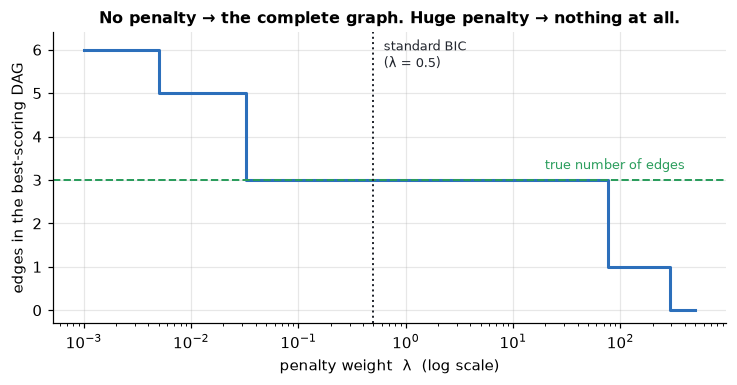

In [6]:
# Precompute the "fit" half of every local score once; only the penalty depends on λ.
PAIRS = [(i, j) for i, j in itertools.permutations(VARS, 2)]
fits = {}
for v in VARS:
    others = [u for u in VARS if u != v]
    for k in range(len(others) + 1):
        for ps in itertools.combinations(others, k):
            fits[(v, frozenset(ps))] = local(v, set(ps), lam=0.0)   # penalty-free fit

def is_dag(parents):
    g = nx.DiGraph()
    g.add_nodes_from(VARS)
    g.add_edges_from(arrows_of(parents))
    return nx.is_directed_acyclic_graph(g)


all_dags = []
for mask in range(1 << len(PAIRS)):
    pa = {v: set() for v in VARS}
    for b, (i, j) in enumerate(PAIRS):
        if mask >> b & 1:
            pa[j].add(i)
    if is_dag(pa):
        all_dags.append(pa)
print(f"{len(all_dags)} DAGs on 4 nodes — we can score them all exactly")


def best_dag(lam):
    best, arg = -np.inf, None
    for pa in all_dags:
        s = sum(fits[(v, frozenset(pa[v]))] - lam * (len(pa[v]) + 1) * np.log(n)
                for v in VARS)
        if s > best:
            best, arg = s, pa
    return arg


lams = np.logspace(-3, 2.7, 50)
n_edges = [sum(len(p) for p in best_dag(lam).values()) for lam in lams]

fig, ax = plt.subplots(figsize=(6.8, 3.6))
ax.step(lams, n_edges, where="post", color=BLUE, linewidth=2)
ax.axhline(3, color=GREEN, linestyle="--", linewidth=1.3)
ax.text(400, 3.25, "true number of edges", ha="right", fontsize=8.5, color=GREEN)
ax.axvline(LAMBDA, color=INK, linestyle=":", linewidth=1.3)
ax.text(LAMBDA * 1.25, 5.6, "standard BIC\n(λ = 0.5)", fontsize=8.5, color=INK)
ax.set_xscale("log")
ax.set_xlabel("penalty weight  λ  (log scale)")
ax.set_ylabel("edges in the best-scoring DAG")
ax.set_title("No penalty → the complete graph. Huge penalty → nothing at all.",
             fontsize=10.5, weight="bold")
ax.set_ylim(-0.3, 6.4); ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

The cell above enumerated them by brute force — all `2^12` ways of orienting the 12
ordered pairs, keeping the acyclic ones — and found **543**. That is few enough to score
every single one at each `λ` and take the exact winner, instead of trusting a greedy
search to find it.

The luxury disappears fast. The count of *labelled* DAGs on `d` nodes
([OEIS A003024](https://oeis.org/A003024)) runs 1, 3, 25, **543**, 29281, 3781503, … and
reaches ≈ `4.2 × 10¹⁸` by `d = 10`. Enumeration is hopeless almost immediately, which is
exactly why score-based discovery needs a search strategy.

The BIC coefficient used in this notebook, `λ = 0.5`, lands on a wide shelf where the
best graph has three edges — the right number. Do not generalise that picture too far:
finite samples, weak effects, model misspecification, and higher dimension can make the
model-selection boundary much less forgiving.

---

## 3. The forward phase, one edge at a time

The search:

> Start from the empty graph. Repeatedly, consider **every** single directed edge you
> could legally add (legal = not already present, and does not create a cycle). Compute
> the change in total score, **ΔBIC**, for each. Add the best one. Stop when no legal
> addition has **positive** gain.

Two properties make this cheap. First, adding `i → j` only changes node `j`'s local
score, so `ΔBIC = local(j, pa(j) ∪ {i}) − local(j, pa(j))` — one regression, not a
rescoring of the whole graph. Second, most candidates' ΔBIC does not change from step to
step, so real implementations cache them.

Below, we recompute everything every step and show you all of it.

In [7]:
acyclic = is_dag          # defined in section 2: no cycles allowed


CAND_EVALS = []            # bookkeeping: how many candidates we scored per round


def candidates(parents, lam=LAMBDA):
    """Every legal single-edge ADDITION, with its ΔBIC. Best first."""
    out = []
    for i, j in itertools.permutations(VARS, 2):
        if i in parents[j]:
            continue
        trial = {v: set(p) for v, p in parents.items()}
        trial[j].add(i)
        if not acyclic(trial):
            continue
        out.append(((i, j), local(j, trial[j], lam) - local(j, parents[j], lam)))
    CAND_EVALS.append(len(out))
    return sorted(out, key=lambda t: -t[1])


def deletions(parents, lam=LAMBDA):
    """Every legal single-edge DELETION, with its ΔBIC. Best first."""
    out = []
    for j in VARS:
        for i in sorted(parents[j]):
            trial = {v: set(p) for v, p in parents.items()}
            trial[j].discard(i)
            out.append(((i, j), local(j, trial[j], lam) - local(j, parents[j], lam)))
    return sorted(out, key=lambda t: -t[1])


def step_figure(parents, cands, winner, step, total):
    """Left: the graph. Right: ΔBIC for every candidate considered."""
    fig, (axg, axb) = plt.subplots(
        1, 2, figsize=(10.6, 4.1), gridspec_kw={"width_ratios": [1, 1.5]})

    draw_state(arrows=[a for a in arrows_of(parents) if a != winner],
               new_arrows=[winner] if winner else [],
               ghost=[e for e, _ in cands if e != winner],
               title=f"Step {step}"
                     + (f":  add {winner[0]} → {winner[1]}" if winner else ":  STOP"),
               caption=f"total score {total:,.1f}", ax=axg)

    names = [f"{i} → {j}" for (i, j), _ in cands][::-1]
    vals = [v for _, v in cands][::-1]
    cols = [BLUE if (cands and e == winner) else (GREY if v <= 0 else "#8fb4d9")
            for (e, v) in cands][::-1]
    axb.barh(names, vals, color=cols, height=0.7)
    axb.axvline(0, color=INK, linewidth=1)
    for k, v in enumerate(vals):
        axb.text(max(v, 0) + 18, k, f"{v:+.1f}", va="center", ha="left",
                 fontsize=8, color="#4a5160")
    axb.set_xlabel("ΔBIC if this edge is added   (positive = improves the score)",
                   fontsize=9)
    axb.set_title("every candidate considered this step", fontsize=10, weight="bold")
    axb.set_xlim(min(min(vals) * 2.5, -60), max(vals) * 1.35 + 60)
    axb.spines[["top", "right", "left"]].set_visible(False)
    axb.tick_params(axis="y", length=0, labelsize=9)
    plt.tight_layout()
    plt.show()


def show_candidates(cands):
    print(f"{'candidate edge':<18}{'ΔBIC':>12}")
    print("-" * 30)
    for (i, j), v in cands:
        print(f"{i + ' → ' + j:<18}{v:>12.2f}")

### Step 0 — from nothing

Twelve candidates (every ordered pair). No cycles are possible yet, so all twelve are
legal.

**Predict before you run.** Which edge do you expect to win? And here is the sharper
question: `C → D` and `D → C` are both on the list. What do you think their scores
will be, relative to each other?

starting score (empty graph): -6748.50

candidate edge            ΔBIC
------------------------------
C → D                  1732.17
D → C                  1732.17
B → C                   409.05
C → B                   409.05
C → A                   404.79
A → C                   404.79
A → D                   316.86
D → A                   316.86
B → D                   315.62
D → B                   315.62
A → B                    -3.74
B → A                    -3.74

best: C → D  (ΔBIC = +1732.17)  new score -5016.33


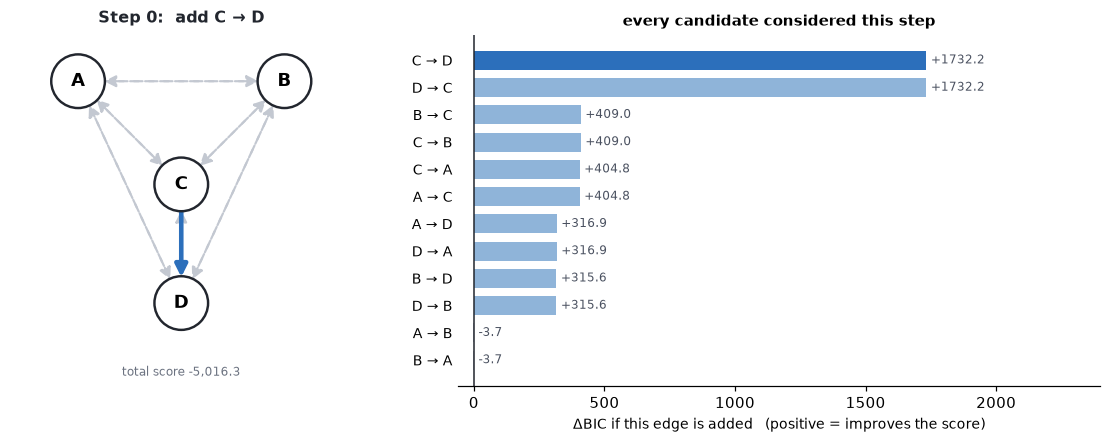

In [8]:
parents = {v: set() for v in VARS}
trajectory = [score(parents)]
print(f"starting score (empty graph): {trajectory[0]:.2f}\n")

cands = candidates(parents)
show_candidates(cands)

winner, best = cands[0]
parents[winner[1]].add(winner[0])
trajectory.append(score(parents))
print(f"\nbest: {winner[0]} → {winner[1]}  (ΔBIC = {best:+.2f})  "
      f"new score {trajectory[-1]:.2f}")
step_figure({v: set(p) for v, p in parents.items()}, cands, winner, 0, trajectory[-1])

`C → D` wins by a mile — it is the strongest single relationship in the data.

Now look at the ties:

```text
C → D    +1732.17
D → C    +1732.17
A → C     +404.79
C → A     +404.79
```

At the empty graph, **every one-edge DAG ties with its reversal**. `X → Y` and `X ← Y`
encode the same conditional-independence statements when those are the only two connected
nodes, so a score-equivalent criterion such as this Gaussian BIC gives them the same
score.

That is the first glimpse of **Markov equivalence**: observational data can identify an
equivalence class without identifying every arrow inside it.

**So why did the search pick `C → D` and not `D → C`?** Nothing statistical.
`candidates()` walks `itertools.permutations(VARS, 2)` and `VARS` is alphabetical, so
`(C, D)` is generated before `(D, C)`. Python's `sorted` is *stable*, so an exact tie
keeps enumeration order, and we take `cands[0]`. The winner is decided by the order the
variables happen to be listed in — nothing else.

Be careful with the scope of that statement. It does **not** mean that the score is
forever blind to every direction. Once other edges are present, `X → Y` and `Y → X` can
imply different collider structure and therefore belong to different equivalence classes;
then their scores can differ. Step 2 will show exactly that.

The PC companion reaches the same equivalence-class boundary through CI tests rather
than through a score. Two utterly different algorithms, stop at the same place by the
same fact about observational data.


In [9]:
# Reverse the variable order and the Step-0 tie breaks the other way.
# Everything else -- data, score, penalty -- is identical.

def greedy(order, lam=LAMBDA):
    """Forward-then-backward hill-climb, enumerating candidates in `order`."""
    pa = {v: set() for v in VARS}
    while True:                                            # forward phase
        moves = []
        for i, j in itertools.permutations(order, 2):
            if i in pa[j]:
                continue
            trial = {v: set(p) for v, p in pa.items()}
            trial[j].add(i)
            if acyclic(trial):
                moves.append(((i, j), local(j, trial[j], lam) - local(j, pa[j], lam)))
        moves.sort(key=lambda t: -t[1])
        if not moves or moves[0][1] <= 0:
            break
        pa[moves[0][0][1]].add(moves[0][0][0])
    while True:                                            # backward phase
        drops = [((i, j), local(j, pa[j] - {i}, lam) - local(j, pa[j], lam))
                 for j in VARS for i in sorted(pa[j])]
        drops.sort(key=lambda t: -t[1])
        if not drops or drops[0][1] <= 0:
            break
        pa[drops[0][0][1]].discard(drops[0][0][0])
    return sorted(arrows_of(pa)), score(pa, lam)


for order in (VARS, VARS[::-1]):
    graph, total = greedy(order)
    edges = ", ".join(f"{i}->{j}" for i, j in graph)
    print(f"enumeration order {order}")
    print(f"   step-0 winner: {'C -> D' if order == VARS else 'D -> C'} "
          f"(tied at +1732.17 either way)")
    print(f"   final graph:   {edges}")
    print(f"   total score:   {total:,.2f}\n")

print(f"truth:            {', '.join(f'{i}->{j}' for i, j in sorted(TRUE_ARROWS))}")


enumeration order ['A', 'B', 'C', 'D']
   step-0 winner: C -> D (tied at +1732.17 either way)
   final graph:   A->C, B->C, C->D
   total score:   -3,919.46

enumeration order ['D', 'C', 'B', 'A']
   step-0 winner: D -> C (tied at +1732.17 either way)
   final graph:   A->B, C->A, C->B, D->C
   total score:   -3,923.20

truth:            A->C, B->C, C->D


Reversing the variable order does not merely relabel the answer, it sends
the search to a **different and worse** local optimum: four edges instead of three, a
total score of `-3,923.20` against `-3,919.46`, and the true DAG gets missed entirely.

So the Step-0 arbitrariness is not cosmetic. The tie itself is genuine — the data really
cannot tell those two one-edge graphs apart — but a greedy hill-climb over **DAGs** has to
*commit* to one of them, and that commitment constrains every move that follows. This is
exactly the weakness GES removes by searching over equivalence classes instead of over
individual DAGs (Section 5).

In [10]:
equivalents = [
    ("A → C → D  (chain)", {"A": set(), "B": set(), "C": {"A"}, "D": {"C"}}),
    ("A ← C → D  (fork)", {"A": {"C"}, "B": set(), "C": set(), "D": {"C"}}),
    ("A ← C ← D  (chain)", {"A": {"C"}, "B": set(), "C": {"D"}, "D": set()}),
    ("A → C ← D  (collider)", {"A": set(), "B": set(), "C": {"A", "D"}, "D": set()}),
]
print(f"{'graph on A, C, D':<26}{'BIC':>14}")
print("-" * 40)
for name, pa in equivalents:
    print(f"{name:<26}{score(pa):>14.4f}")
print("\nThe first three are Markov equivalent -> identical to the last decimal.")
print("The collider is NOT equivalent -> a different, worse score. Scores can see")
print("colliders; they cannot see the difference between a chain and a fork.")

graph on A, C, D                     BIC
----------------------------------------
A → C → D  (chain)            -4611.5409
A ← C → D  (fork)             -4611.5409
A ← C ← D  (chain)            -4611.5409
A → C ← D  (collider)         -4932.1753

The first three are Markov equivalent -> identical to the last decimal.
The collider is NOT equivalent -> a different, worse score. Scores can see
colliders; they cannot see the difference between a chain and a fork.


### Step 1

`C → D` is now in the model. Two candidates just disappeared (`C → D` is taken,
`D → C` would make a cycle). But something more interesting has happened to the ones
that remain.

**Predict before you run.** At step 0, `A → D` scored `+316.86` — a big improvement.
What is it worth now that `C → D` is in the model?

candidate edge            ΔBIC
------------------------------
B → C                   409.05
C → B                   409.05
C → A                   404.79
A → C                   404.79
D → A                   316.86
D → B                   315.62
B → D                    -3.59
A → B                    -3.74
B → A                    -3.74
A → D                    -3.77

best: B → C  (ΔBIC = +409.05)  new score -4607.28


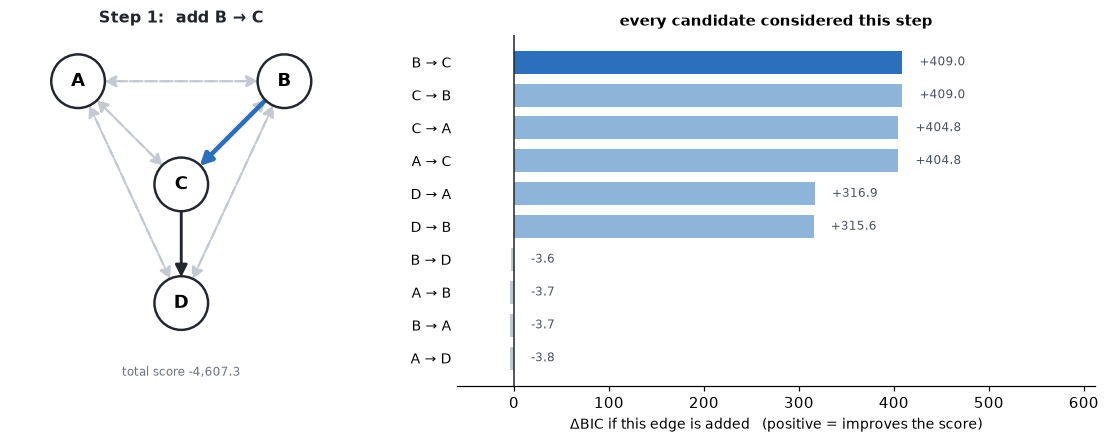

In [11]:
cands = candidates(parents)
show_candidates(cands)

winner, best = cands[0]
parents[winner[1]].add(winner[0])
trajectory.append(score(parents))
print(f"\nbest: {winner[0]} → {winner[1]}  (ΔBIC = {best:+.2f})  "
      f"new score {trajectory[-1]:.2f}")
step_figure({v: set(p) for v, p in parents.items()}, cands, winner, 1, trajectory[-1])

Let's analyze what happened to `A → D`. In the first round it scored **+316.86**, one of the
best edges available. Now it scores **−3.77** and the penalty rejects it.

`A` and `D` haven't changed. What's different is that `D` now has `C` as a parent, and
whatever `A` had to say about `D`, it was saying through `C`. With `C` already in the
regression, `A` adds nothing except a parameter that gets penalized.

This is the score-based analogue of PC deleting the `A–D` edge because `A ⊥ D | C`. Same
fact about the data, discovered by a completely different mechanism: PC ran a hypothesis
test; the score just watched an edge stop paying rent.

### Step 2

`C` now has one parent, `B`. Watch what that does to the *other* parent candidate.

**Predict before you run.** At step 0, `A → C` was worth `+404.79`. Now that `B → C` is
in the model — is `A → C` worth more, less, or about the same?

candidate edge            ΔBIC
------------------------------
A → C                   687.83
C → A                   404.79
D → A                   316.86
B → D                    -3.59
A → B                    -3.74
B → A                    -3.74
A → D                    -3.77

best: A → C  (ΔBIC = +687.83)  new score -3919.46


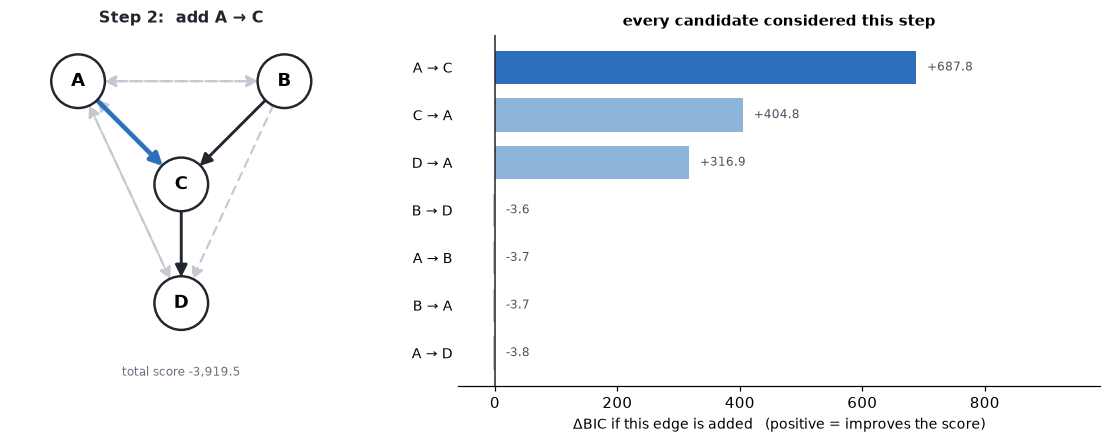

In [12]:
cands = candidates(parents)
show_candidates(cands)

winner, best = cands[0]
parents[winner[1]].add(winner[0])
trajectory.append(score(parents))
print(f"\nbest: {winner[0]} → {winner[1]}  (ΔBIC = {best:+.2f})  "
      f"new score {trajectory[-1]:.2f}")
step_figure({v: set(p) for v, p in parents.items()}, cands, winner, 2, trajectory[-1])

`A → C` went **up**, from `+404.79` to `+687.83`. Adding `B` as one parent of `C`
made the other true parent more valuable, not less.

This is the **score-side signature of the collider structure**. In the generating model,
`C = A + B + noise`. When `B` is absent from the local model for `C`, its contribution is
part of the residual variation. Once `B` is included, the incremental contribution of
`A` becomes clearer, so the gain from adding `A → C` rises.

This is closely related to the textbook *explaining-away* phenomenon: for a collider
`A → C ← B`, `A` and `B` can be marginally independent yet become dependent after
conditioning on their common child `C`. PC detects that pattern with CI tests; a
score-based search encounters the same distributional structure through changes in local fit.

Under the standard Markov-equivalence framework, **unshielded colliders are the local
patterns that distinguish equivalence classes**. They are therefore central to what can
be oriented from ordinary observational conditional-independence information. Stronger assumptions, interventions, temporal order, or background knowledge can identify more.


### Step 3 — stopping

Every remaining candidate now costs more in penalty than it recovers in fit.

candidate edge            ΔBIC
------------------------------
B → D                    -3.59
A → B                    -3.74
B → A                    -3.74
A → D                    -3.77

best available ΔBIC is -3.59 <= 0  ->  STOP


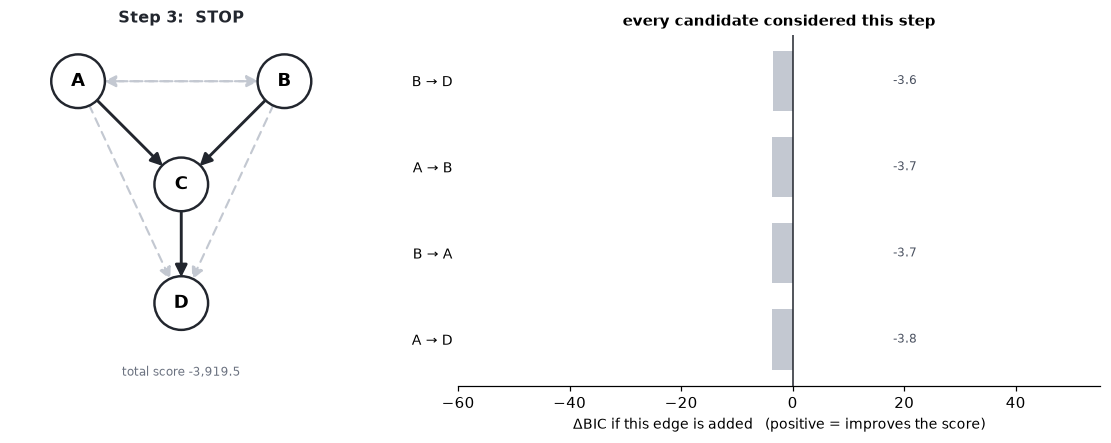


forward phase result:
  parents(A) = {}
  parents(B) = {}
  parents(C) = {A, B}
  parents(D) = {C}

Exactly the true DAG.


In [13]:
cands = candidates(parents)
show_candidates(cands)

if cands[0][1] <= 0:
    print(f"\nbest available ΔBIC is {cands[0][1]:+.2f} <= 0  ->  STOP")
step_figure({v: set(p) for v, p in parents.items()}, cands, None, 3, trajectory[-1])

forward_result = {v: set(p) for v, p in parents.items()}
print("\nforward phase result:")
for v in VARS:
    print(f"  parents({v}) = " + "{" + ", ".join(sorted(parents[v])) + "}")
assert forward_result == TRUE_PARENTS, forward_result
print("\nExactly the true DAG.")

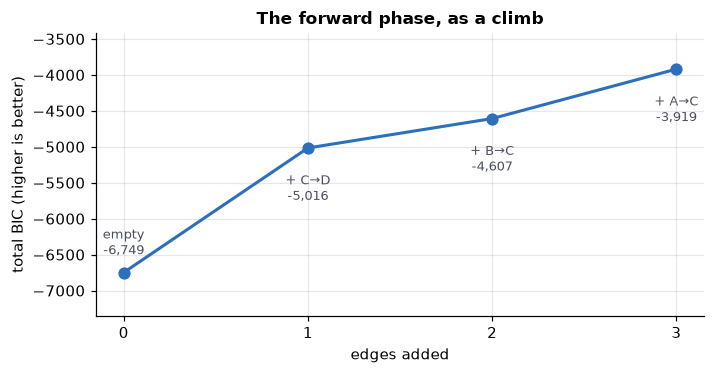

In [14]:
fig, ax = plt.subplots(figsize=(6.6, 3.5))
ax.plot(range(len(trajectory)), trajectory, "o-", color=BLUE, linewidth=2,
        markersize=7)
for k, s in enumerate(trajectory):
    lbl = ["empty", "+ C→D", "+ B→C", "+ A→C"][k]
    ax.annotate(f"{lbl}\n{s:,.0f}", (k, s), textcoords="offset points",
                xytext=(0, -34 if k else 12), ha="center", fontsize=8.5,
                color="#4a5160")
ax.set_xticks(range(len(trajectory)))
ax.set_xlabel("edges added"); ax.set_ylabel("total BIC (higher is better)")
ax.set_title("The forward phase, as a climb", fontsize=11, weight="bold")
ax.set_ylim(min(trajectory) - 600, max(trajectory) + 500)
ax.grid(alpha=0.3); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

> ### Recap — forward phase
>
> | step | winner | ΔBIC | why it was the winner |
> |---|---|---|---|
> | 0 | `C → D` | +1732.17 | strongest relationship; its reversal tied |
> | 1 | `B → C` | +409.05 | `A → D` had collapsed to −3.77 once `C → D` explained it |
> | 2 | `A → C` | +687.83 | its gain rose once the other collider parent was present |
> | 3 | — | ≤ 0 | no remaining addition improves BIC |
>
> Three additions happen to produce the true DAG in this run. But do not read the chosen
> arrow on every tied move as identified by the data. **Within a Markov equivalence class,
> the score ties; search order and acyclicity pick the representative.** As the
> reversed-order experiment showed, that pick is not always harmless — here it decided
> whether the search found the true DAG at all.
>
> When a candidate *changes* the equivalence class — by creating or avoiding an unshielded
> collider — the score can genuinely prefer one structure over another. Step 2 was that
> case.


---

## 4. The backward phase

Forward search only adds. At each step it takes the edge that looks best given the graph so far, and it never reconsiders. But we just saw that the value of an edge depends on
what else is in the graph: `A → D` was worth +316.86 until `C → D` went in. An edge we added at step 0 can be
left redundant by something we add at step 3, and the forward phase has no way to notice.

So score-based methods follow the forward phase with a **backward phase**: repeatedly
delete the single edge whose removal most improves the score, until no deletion helps.

On this run, no deletion helps on the first attempt, so the backward phase stops
immediately and the graph comes out unchanged.


In [15]:
dels = deletions(parents)
print(f"{'delete this edge':<20}{'ΔBIC':>12}")
print("-" * 32)
for (i, j), v in dels:
    print(f"{i + ' → ' + j:<20}{v:>12.2f}")
print(f"\nbest deletion is {dels[0][1]:+.2f} <= 0  ->  nothing removed. "
      f"The graph survives unchanged.")

delete this edge            ΔBIC
--------------------------------
A → C                    -687.83
B → C                    -692.08
C → D                   -1732.17

best deletion is -687.83 <= 0  ->  nothing removed. The graph survives unchanged.


### When the backward phase earns its keep

To see it work, we need a run where forward search actually overshoots. Same system,
same generating equations — just 60 samples instead of 2000.

In [22]:
def greedy_two_phase(data, lam=LAMBDA, verbose=True):
    """Full two-phase greedy search. Returns (after_forward, after_backward)."""
    def loc(node, ps):
        return local(node, ps, lam, data)

    def sc(pa):
        return sum(loc(v, pa[v]) for v in VARS)

    pa = {v: set() for v in VARS}
    while True:
        best = None
        for i, j in itertools.permutations(VARS, 2):
            if i in pa[j]:
                continue
            trial = {v: set(p) for v, p in pa.items()}
            trial[j].add(i)
            if not acyclic(trial):
                continue
            delta = loc(j, trial[j]) - loc(j, pa[j])
            if best is None or delta > best[0]:
                best = (delta, i, j)
        if best is None or best[0] <= 0:
            break
        if verbose:
            print(f"  forward: add {best[1]} → {best[2]}   ΔBIC {best[0]:+9.2f}")
        pa[best[2]].add(best[1])
    fwd = {v: set(p) for v, p in pa.items()}

    while True:
        best = None
        for j in VARS:
            for i in sorted(pa[j]):
                trial = {v: set(p) for v, p in pa.items()}
                trial[j].discard(i)
                delta = loc(j, trial[j]) - loc(j, pa[j])
                if best is None or delta > best[0]:
                    best = (delta, i, j)
        if best is None or best[0] <= 0:
            break
        if verbose:
            print(f"  backward: drop {best[1]} → {best[2]}   ΔBIC {best[0]:+9.2f}")
        pa[best[2]].discard(best[1])
    return fwd, pa


r = np.random.default_rng(33)
n_s = 60
a_s = r.standard_normal(n_s)
b_s = r.standard_normal(n_s)
c_s = a_s + b_s + r.standard_normal(n_s)
d_s = 1.2 * c_s + r.standard_normal(n_s)
X_small = np.column_stack([a_s, b_s, c_s, d_s])

print(f"greedy search on n = {n_s}:")
fwd_small, bwd_small = greedy_two_phase(X_small)
print("\nafter forward: ", {v: sorted(p) for v, p in fwd_small.items()})
print("after backward:", {v: sorted(p) for v, p in bwd_small.items()})

greedy search on n = 60:
  forward: add C → D   ΔBIC    +39.73
  forward: add D → A   ΔBIC     +5.39
  forward: add B → A   ΔBIC     +5.68
  forward: add B → C   ΔBIC     +3.93
  forward: add C → A   ΔBIC     +0.70
  backward: drop D → A   ΔBIC     +1.52

after forward:  {'A': ['B', 'C', 'D'], 'B': [], 'C': ['B'], 'D': ['C']}
after backward: {'A': ['B', 'C'], 'B': [], 'C': ['B'], 'D': ['C']}


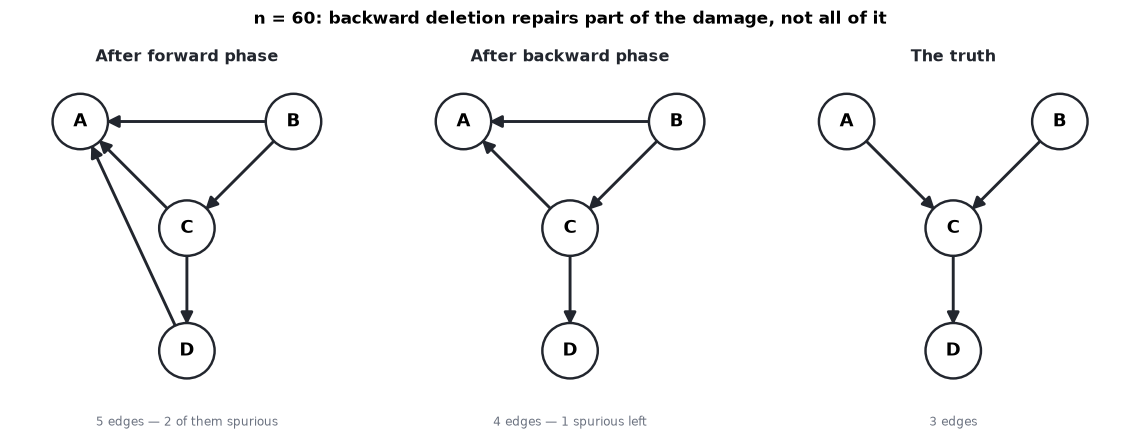

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(10.6, 3.9))
draw_state(arrows=arrows_of(fwd_small), title="After forward phase",
           caption=f"{len(arrows_of(fwd_small))} edges — 2 of them spurious",
           ax=axes[0])
draw_state(arrows=arrows_of(bwd_small), title="After backward phase",
           caption=f"{len(arrows_of(bwd_small))} edges — 1 spurious left",
           ax=axes[1])
draw_state(arrows=TRUE_ARROWS, title="The truth", caption="3 edges", ax=axes[2])
fig.suptitle(f"n = {n_s}: backward deletion repairs part of the damage, not all of it",
             fontsize=11, weight="bold", y=1.03)
plt.tight_layout()
plt.show()

Trace what happened. Forward search's second move was `D → A` — a shortcut edge, since
`A` and `D` are related only through `C`. Three moves later, with both `C → A` and
`C → D` in the model, that shortcut had become redundant. Forward search had no way to
undo it. Backward deletion found it and removed it, for a gain of `+1.52`.

Now read the figure honestly. The final graph is **still wrong**. A spurious `A – B` edge
survives, `A` has acquired two parents it does not have, and the `A – C` arrow points the
wrong way.

Two lessons:

1. Backward deletion is a genuine repair mechanism for the greediness of forward search.
2. It is a repair, **not a guarantee**. Greedy search can walk into a local optimum that
   no single-edge deletion escapes. On 60 samples of a four-variable system, it does.

---

## 5. What we ran, and what GES actually does

Be clear about what you just watched. It was **greedy hill-climbing over DAGs**: one
edge at a time, forward then backward, on a fixed scoring function. It is the honest
skeleton of the idea and it behaves the way real score-based methods behave.

**GES** — Greedy Equivalence Search, the algorithm the literature means by "score-based"
— differs in one important way. Because scores cannot distinguish Markov-equivalent DAGs
(Section 3), GES does not search over DAGs at all. It searches over **equivalence
classes**, using Insert and Delete operators that move between classes rather than
between individual graphs. That change matters theoretically: given a consistent (more
precisely, locally consistent) score and the usual causal-DAG assumptions, GES is
asymptotically consistent for the correct Markov equivalence class. Our naive DAG
hill-climb inherits no such guarantee.

`causal-ts` wraps GES for time series as `causalts.baselines.ges_discovery` (and the
less-greedy variant as `lges_discovery`). Here we call causal-learn's `ges` directly so
you can see exactly what goes in and what comes out. Let's check it agrees with us on the
full sample.

In [24]:
from causallearn.graph.Endpoint import Endpoint
from causallearn.search.ScoreBased.GES import ges


def read_edges(G, names):
    """Turn a causal-learn graph into a readable edge list."""
    out = []
    for e in G.get_graph_edges():
        u = names[G.get_nodes().index(e.get_node1())]
        v = names[G.get_nodes().index(e.get_node2())]
        head1, head2 = e.get_endpoint1(), e.get_endpoint2()
        if head2 == Endpoint.ARROW and head1 == Endpoint.TAIL:
            out.append(f"{u} → {v}")
        elif head1 == Endpoint.ARROW and head2 == Endpoint.TAIL:
            out.append(f"{v} → {u}")
        else:
            out.append(f"{u} – {v}   (direction not identified)")
    return out


res = ges(X, score_func="local_score_BIC", parameters={"lambda_value": LAMBDA})
print("GES output:")
for line in read_edges(res["G"], VARS):
    print("  " + line)

print("\nour hill-climb:", sorted(arrows_of(forward_result)))
print("truth:         ", sorted(TRUE_ARROWS))

GES output:
  A → C
  B → C
  C → D

our hill-climb: [('A', 'C'), ('B', 'C'), ('C', 'D')]
truth:          [('A', 'C'), ('B', 'C'), ('C', 'D')]


---

## 6. Head to head with PC

Same 2000 samples, same four variables, two algorithms that share no machinery
whatsoever. Let's run PC here too — a compact version of the algorithm derived in the
[companion notebook](pc_step_by_step.ipynb) — and put the answers side by side.

In [19]:
from causalts.ci_tests import ParCorrGPU

cit = ParCorrGPU(X, device="cpu")
n_ci_tests = 0


def pc(alpha=0.05):
    """Compact PC — see the companion notebook for the full derivation."""
    global n_ci_tests

    def t(x, y, S):
        global n_ci_tests
        n_ci_tests += 1
        return float(cit(IDX[x], IDX[y], [IDX[s] for s in S])[0])

    E = {frozenset(e) for e in itertools.combinations(VARS, 2)}
    sep, depth = {}, 0
    while E:
        nb = {v: {w for e in E if v in e for w in e if w != v} for v in VARS}
        cand = {e: sorted((nb[x] | nb[y]) - {x, y})
                for e in E for x, y in [sorted(e)]}
        if max(len(c) for c in cand.values()) < depth:
            break
        for e in sorted(E, key=lambda s: sorted(s)):
            x, y = sorted(e)
            for S in itertools.combinations(cand[e], depth):
                if t(x, y, S) > alpha:
                    E.discard(e)
                    sep[e] = set(S)
                    break
        depth += 1

    arr = set()
    for z in VARS:                                              # collider rule
        nbz = sorted({w for e in E if z in e for w in e if w != z})
        for x, y in itertools.combinations(nbz, 2):
            if frozenset((x, y)) not in E and z not in sep.get(frozenset((x, y)), {z}):
                arr |= {(x, z), (y, z)}
    changed = True
    while changed:                                              # Meek R1
        changed = False
        for a_, b_ in list(arr):
            for c_ in {w for e in E if b_ in e for w in e if w != b_}:
                if c_ != a_ and (b_, c_) not in arr and (c_, b_) not in arr \
                        and frozenset((a_, c_)) not in E:
                    arr.add((b_, c_)); changed = True
    return arr


pc_arrows = pc()
print(f"PC:           {sorted(pc_arrows)}   ({n_ci_tests} CI tests)")
print(f"score search: {sorted(arrows_of(forward_result))}   "
      f"({len(CAND_EVALS)} rounds, {sum(CAND_EVALS)} candidate scorings)")
print(f"truth:        {sorted(TRUE_ARROWS)}")

PC:           [('A', 'C'), ('B', 'C'), ('C', 'D')]   (19 CI tests)
score search: [('A', 'C'), ('B', 'C'), ('C', 'D')]   (4 rounds, 33 candidate scorings)
truth:        [('A', 'C'), ('B', 'C'), ('C', 'D')]


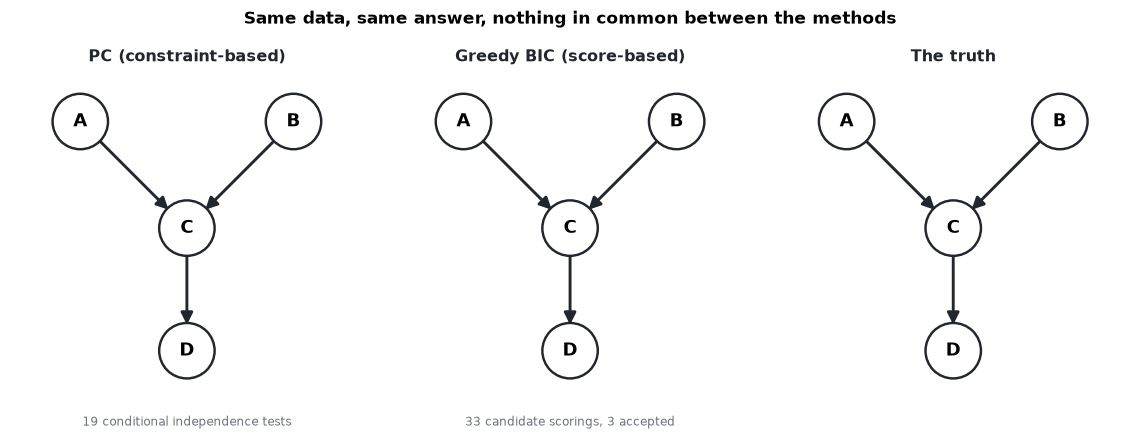

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(10.6, 3.9))
draw_state(arrows=sorted(pc_arrows), title="PC (constraint-based)",
           caption=f"{n_ci_tests} conditional independence tests", ax=axes[0])
draw_state(arrows=arrows_of(forward_result), title="Greedy BIC (score-based)",
           caption=f"{sum(CAND_EVALS)} candidate scorings, 3 accepted", ax=axes[1])
draw_state(arrows=TRUE_ARROWS, title="The truth", caption="", ax=axes[2])
fig.suptitle("Same data, same answer, nothing in common between the methods",
             fontsize=11, weight="bold", y=1.03)
plt.tight_layout()
plt.show()

| | **Constraint-based (PC)** | **Score-based (GES / hill-climb)** |
|---|---|---|
| starts from | complete graph | empty graph / equivalence class |
| moves by | deleting edges that CI evidence separates | score-improving Insert/Delete moves |
| consumes | CI-test statistics and p-values | a statistical score such as BIC |
| key knob | significance level `alpha` | score choice and penalty weight |
| orients via | unshielded colliders + Meek propagation | differences between equivalence classes |
| extra assumption | the CI test must match the data | the score's model family must match the data |
| fails by | unstable CI decisions cascading | noisy scores, greedy moves, local optima |
| natural strength | sparse graphs, flexible nonparametric CI tests | a credible score and a manageable search space |
| returns | a CPDAG | a CPDAG (GES) or one representative (hill-climb) |

---

## 7. Putting the time axis back

Same structure, now unfolding over time:

$$C_t = A_{t-1} + B_{t-1} + \varepsilon, \qquad D_t = 1.2\,C_{t-1} + \varepsilon.$$

A useful **baseline** is lag embedding: build a wide table with
`A(t), B(t), C(t), D(t), A(t−1), B(t−1), C(t−1), D(t−1)` and hand that table to an
ordinary score search.

This is pedagogically useful because it separates two ideas:

1. The score can discover statistical structure across lagged columns;
2. A generic cross-sectional GES search does **not** automatically know that `(t−1)` is
   earlier than `t` unless temporal background constraints are supplied.

So the next cell is intentionally a naive lag-embedded baseline, not a claim that time
series require no additional structure.


In [25]:
T = 2000
r = np.random.default_rng(SEED)
a = r.standard_normal(T)
b = r.standard_normal(T)
c = np.zeros(T)
d = np.zeros(T)
for t in range(1, T):
    c[t] = a[t - 1] + b[t - 1] + r.standard_normal()
    d[t] = 1.2 * c[t - 1] + r.standard_normal()

df_ts = pd.DataFrame({"A": a, "B": b, "C": c, "D": d})

# --- lag embedding: present block beside the lag-1 block -----------------
MAX_LAG = 1
blocks = [df_ts.values[MAX_LAG - lag: T - lag, :] for lag in range(MAX_LAG + 1)]
embedded = np.hstack(blocks)
emb_names = [f"{v}(t)" for v in VARS] + [f"{v}(t-1)" for v in VARS]

print(f"embedded matrix: {embedded.shape[0]} rows x {embedded.shape[1]} columns")
print("columns:", ", ".join(emb_names), "\n")

res_ts = ges(embedded, score_func="local_score_BIC",
             parameters={"lambda_value": LAMBDA})
print("edges found:")
for line in read_edges(res_ts["G"], emb_names):
    print("  " + line)
print("\ntrue edges:  A(t-1) → C(t),  B(t-1) → C(t),  C(t-1) → D(t)")

embedded matrix: 1999 rows x 8 columns
columns: A(t), B(t), C(t), D(t), A(t-1), B(t-1), C(t-1), D(t-1) 

edges found:
  A(t-1) → C(t)
  B(t-1) → C(t)
  D(t) – C(t-1)   (direction not identified)

true edges:  A(t-1) → C(t),  B(t-1) → C(t),  C(t-1) → D(t)


**What the time axis buys you once you use it.** In the cross-sectional run some
orientations were tied inside an equivalence class. For a genuinely lagged relation we
also know causes cannot run backward in time, so a time-aware procedure can force
`A(t−1) → C(t)`.

The output above shows why plain lag embedding is not enough on its own: `C(t−1) – D(t)`
came back **undirected**. Generic GES sees two columns and has no idea one is earlier. A time-series-aware method — or GES given temporal background knowledge — can impose the past-to-future constraint.

What temporal order does *not* settle is contemporaneous structure. For interactions inside one time step, time gives no direction and equivalence-class logic returns.

**What lag embedding costs** is dimension. Four variables at `max_lag = 1` become eight
columns; at `max_lag = 5`, twenty-four. That blow-up is one reason time-series methods
exploit temporal constraints instead of treating embedded columns as unrelated variables.

---

## Try it yourself

Change one thing at a time, and predict what the search will do:

1. Sweep `lambda` around `0.5`. When does the best graph turn too dense or too sparse?
2. Drop to `n = 100`. How stable are the winning moves across seeds?
3. Weaken `A → C` from `1.0` to `0.2`. Does forward search still find the collider?
4. Compare the naive hill-climb with GES. Which differences are just different
   representatives of one equivalence class, and which change the class itself?
5. Add temporal background knowledge to the lag-embedded example and check that
   `C(t−1) → D(t)` is no longer left unoriented.

---

## Key takeaways

1. A score is **fit minus complexity**. Without the penalty, extra edges are rewarded for
   improving fit even when they add no real structure.
2. Greedy forward search adds the **best move available now**; candidate gains change as
   the graph grows.
3. Adding an edge can make another **worthless** (a shortcut now explained) or **more
   valuable** (a collider's other parent). Both happened here in three steps.
4. Within a Markov equivalence class the score **ties**, and search order picks the
   representative. Moves that change the class *can* be scored apart.
5. Greedy search gets stuck. The backward phase repairs some of it, GES's search over
   equivalence classes more — neither makes small-sample results trustworthy.

## Where to go next

| you want to | go here |
|---|---|
| See the constraint-based family in the same detail | [How the PC Algorithm Works](pc_step_by_step.ipynb) |
| Get the conceptual background | [Beginner's Guide](beginners_guide.ipynb) |
| Run all four `causal-ts` algorithms on real data | [Getting Started Tutorial](../tutorial.ipynb) |
| Compare against GES, DYNOTEARS and friends | [Baseline comparison](baseline_comparison.ipynb) |
| Diagnose hidden confounding | [Latent confounder detection](latent_confounder_detection.ipynb) |
| See a hybrid constraint + learned-score method | [GRACE high-dimensional](grace_high_dim.ipynb) |
| Turn a discovered graph into an effect estimate | [Effect estimation](effect_estimation.ipynb) |

### References

- Chickering (2002), *Optimal Structure Identification With Greedy Search* — the theory
  behind GES.
- Chickering (1995), *A Transformational Characterization of Equivalent Bayesian Network
  Structures* — Markov equivalence and covered-edge reversals.